# BÀI THỰC HÀNH 5: KIẾN TRÚC TRANSFORMER ENCODER

Họ tên: Trần Nhật Phương Anh  
MSSV: 23520078

<b>Hướng dẫn nộp bài:</b> Các bạn commit và push code lên github, sử dụng file txt đặt tên theo cú pháp <MSSV>.txt chứa đường link dẫn đến github của bài thực hành và nộp file txt này tên courses.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from collections import Counter
import torch.nn.functional as F
import math
import seaborn as sns
from sklearn.metrics import confusion_matrix
import regex as re
import unicodedata
from underthesea import word_tokenize

In [2]:
train = pd.read_json('UIT-ViOCD/train.json').T
dev = pd.read_json('UIT-ViOCD/dev.json').T
test = pd.read_json('UIT-ViOCD/test.json').T

In [3]:
# In 20 dòng đầu
print('20 dòng đầu trong tập Train:')
print(train.head(20))

print('\n20 dòng đầu trong tập Dev:')
print(dev.head(20))

print('\n20 dòng đầu trong tập Test:')
print(test.head(20))

20 dòng đầu trong tập Train:
                                               review          label    domain
0   gói hàng cẩn thận . chơi pubg với lie...  non-complaint    mobile
1   mình góp ý thật nhé . . đừng bắt pha...      complaint       app
2   máy khá đẹp , pin trâu vân tay nhạy nhạ...      complaint    mobile
3   một mớ lỗi : không xem lại được bà...      complaint       app
4   đặc mẫu xanh mà sao giao mẫu này vậy...      complaint   fashion
5   đẹp lam luon . . . ung hộ cửa hàng dài ...  non-complaint   fashion
6                máy mới nguyên zin rất được  non-complaint    mobile
7   hàng giao nhanh mới đặt từ trưa qua ma...  non-complaint  cosmetic
8                    sản phẩm đẹp . rất ưng ý  non-complaint   fashion
9   mình hồi trước có xài thử decumar nh...  non-complaint  cosmetic
10  tôi cập nhật lại ap hack não này từ ...      complaint       app
11  mình mới tiếp 

In [4]:
# Số câu trong train/dev/test
print('Số câu trong tập Train:', len(train))
print('Số câu trong tập Dev:', len(dev))
print('Số câu trong tập Test:', len(test))

Số câu trong tập Train: 4387
Số câu trong tập Dev: 548
Số câu trong tập Test: 549


In [5]:
# Kiểm tra các cột có trong dataset 
print('Train: ', train.columns.tolist())
print('Dev: ', dev.columns.tolist())
print('Test: ', test.columns.tolist())

Train:  ['review', 'label', 'domain']
Dev:  ['review', 'label', 'domain']
Test:  ['review', 'label', 'domain']


In [6]:
# Thống kê tần suất mỗi nhãn
print('Phân phối nhãn trong tập Train: \n', train['domain'].value_counts())
print('Phân phối nhãn trong tập Dev: \n', dev['domain'].value_counts())
print('Phân phối nhãn trong tập Test: \n', test['domain'].value_counts())

Phân phối nhãn trong tập Train: 
 domain
app         1613
fashion     1368
cosmetic    1043
mobile       363
Name: count, dtype: int64
Phân phối nhãn trong tập Dev: 
 domain
app         203
fashion     156
cosmetic    135
mobile       54
Name: count, dtype: int64
Phân phối nhãn trong tập Test: 
 domain
app         194
fashion     159
cosmetic    150
mobile       46
Name: count, dtype: int64


C:\Users\Phuong Anh\AppData\Local\Temp\ipykernel_6436\3252694163.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='domain', data=train, ax=axes[0], palette='pastel')
C:\Users\Phuong Anh\AppData\Local\Temp\ipykernel_6436\3252694163.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='domain', data=dev, ax=axes[1], palette='pastel')
C:\Users\Phuong Anh\AppData\Local\Temp\ipykernel_6436\3252694163.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='domain', data=test, ax=axes[2], palette='pastel')


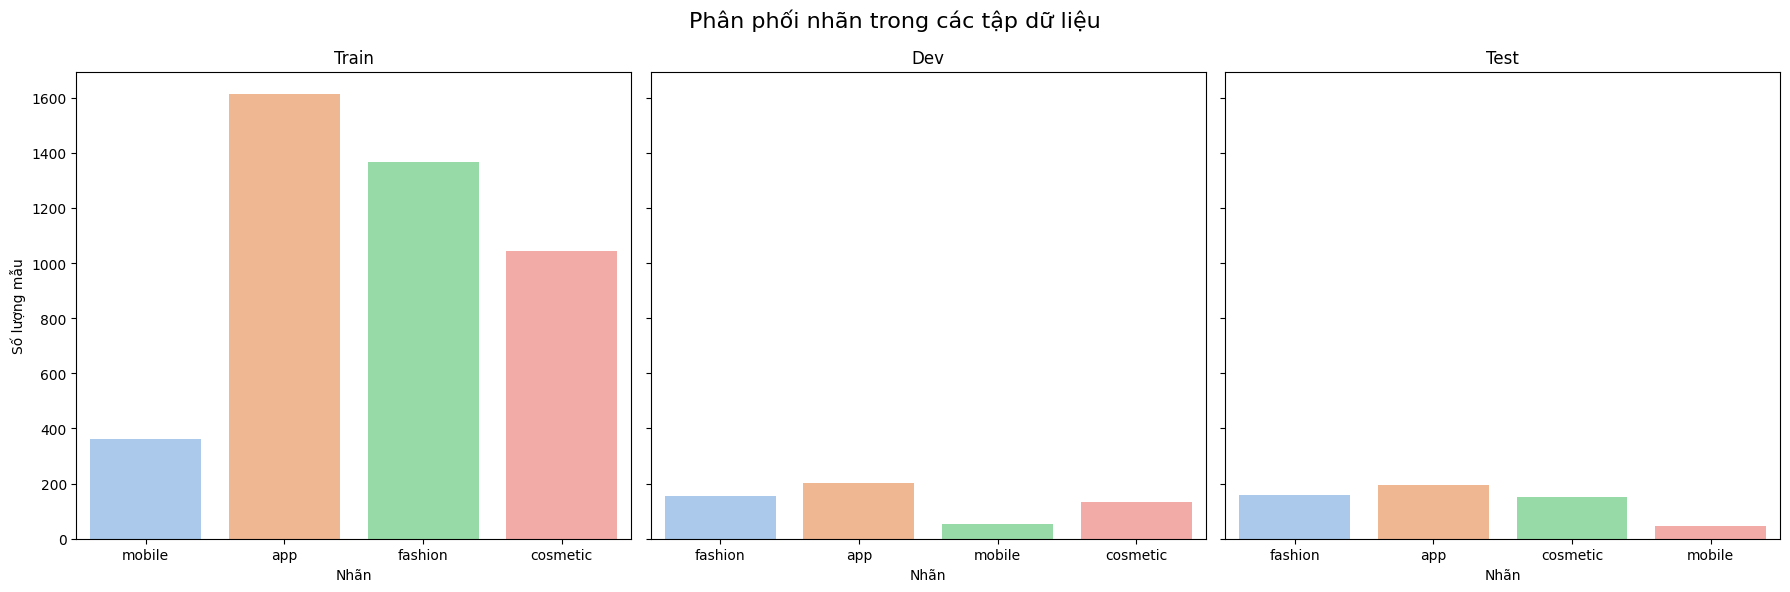

In [7]:
# Vẽ biểu đồ (bar chart) phân bố nhãn.
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

sns.countplot(x='domain', data=train, ax=axes[0], palette='pastel')
axes[0].set_title('Train')
axes[0].set_xlabel('Nhãn')
axes[0].set_ylabel('Số lượng mẫu')

sns.countplot(x='domain', data=dev, ax=axes[1], palette='pastel')
axes[1].set_title('Dev')
axes[1].set_xlabel('Nhãn')
axes[1].set_ylabel('')

sns.countplot(x='domain', data=test, ax=axes[2], palette='pastel')
axes[2].set_title('Test')
axes[2].set_xlabel('Nhãn')
axes[2].set_ylabel('')

plt.suptitle('Phân phối nhãn trong các tập dữ liệu', fontsize=16)
plt.tight_layout()
plt.show()


- Tập huấn luyện có sự mất cân bằng rõ rệt giữa các nhãn, đặc biệt app và fashion chiếm ưu thế.
- Tập kiểm tra và tập phát triển có phân phối tương đối đồng đều giữa các nhãn, ngoại trừ mobile có số lượng thấp hơn đáng kể.

In [8]:
# Tính số token/word trong từng câu.
train['word_count'] = train['review'].apply(lambda x: len(x.split()))
dev['word_count'] = dev['review'].apply(lambda x: len(x.split()))
test['word_count'] = test['review'].apply(lambda x: len(x.split()))

# Thống kê độ dài câu.
print('Thống kê độ dài câu trong tập Train:\n', train['word_count'].describe())
print('Thống kê độ dài câu trong tập Dev:\n', dev['word_count'].describe())
print('Thống kê độ dài câu trong tập Test:\n', test['word_count'].describe())

Thống kê độ dài câu trong tập Train:
 count    4387.000000
mean       31.653294
std        28.541406
min         1.000000
25%         9.000000
50%        20.000000
75%        49.500000
max       256.000000
Name: word_count, dtype: float64
Thống kê độ dài câu trong tập Dev:
 count    548.000000
mean      32.562044
std       27.960238
min        1.000000
25%        9.000000
50%       22.000000
75%       55.250000
max       95.000000
Name: word_count, dtype: float64
Thống kê độ dài câu trong tập Test:
 count    549.000000
mean      31.903461
std       29.616154
min        1.000000
25%        9.000000
50%       21.000000
75%       48.000000
max      293.000000
Name: word_count, dtype: float64


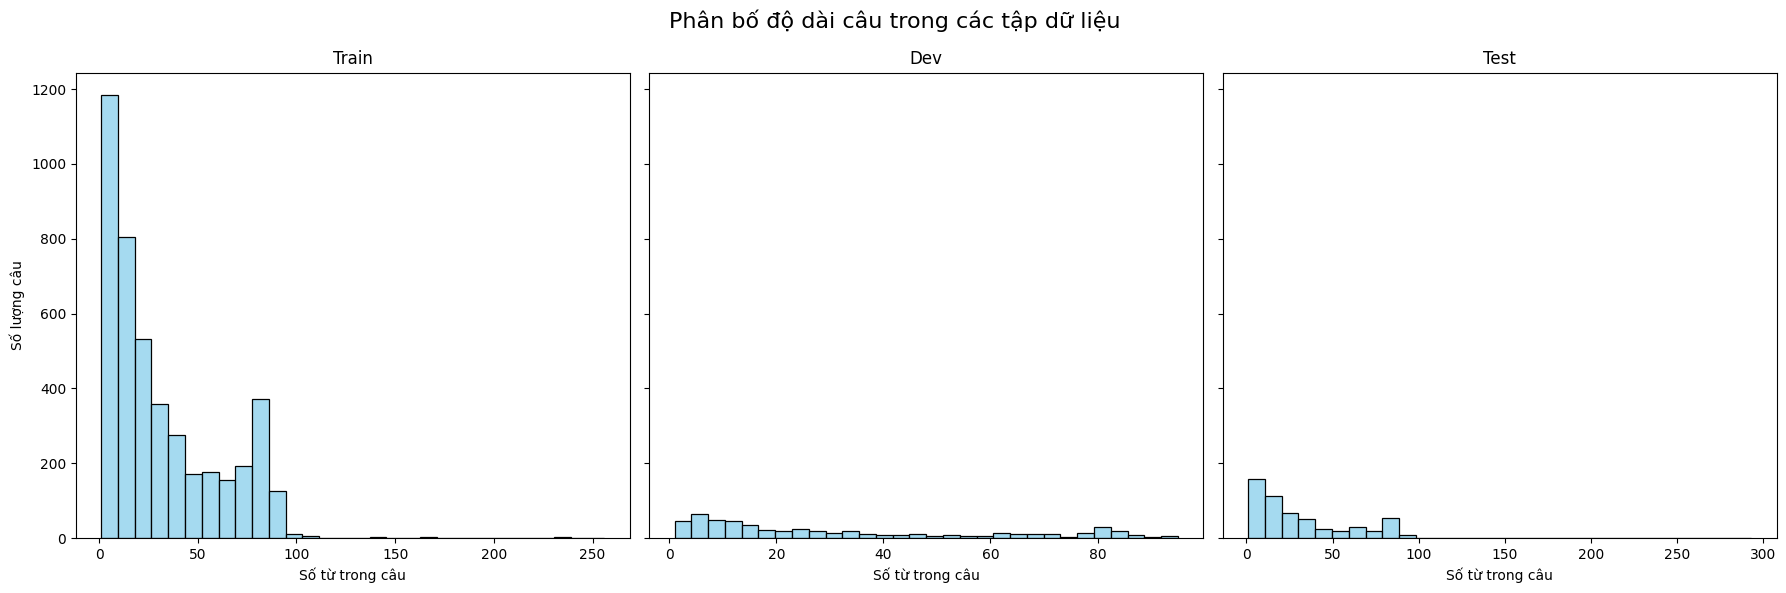

In [9]:
# Vẽ biểu đồ phân bố độ dài câu.
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

sns.histplot(train['word_count'], bins=30, ax=axes[0], color='skyblue')
axes[0].set_title('Train')
axes[0].set_xlabel('Số từ trong câu')
axes[0].set_ylabel('Số lượng câu')

sns.histplot(dev['word_count'], bins=30, ax=axes[1], color='skyblue')
axes[1].set_title('Dev')
axes[1].set_xlabel('Số từ trong câu')
axes[1].set_ylabel('')

sns.histplot(test['word_count'], bins=30, ax=axes[2], color='skyblue')
axes[2].set_title('Test')
axes[2].set_xlabel('Số từ trong câu')
axes[2].set_ylabel('')

plt.suptitle('Phân bố độ dài câu trong các tập dữ liệu', fontsize=16)
plt.tight_layout()
plt.show()

Train
- Phân bố tập trung ở khoảng 10–20 từ mỗi câu.
- Số lượng câu ngắn chiếm ưu thế rõ rệt.

Dev
- Phân bố trải rộng hơn so với tập Train.
- Vẫn nghiêng về các câu ngắn, nhưng có sự đa dạng hơn về độ dài.

Test
- Phân bố tương tự tập Dev.
- Câu ngắn vẫn chiếm phần lớn.

In [10]:
def ratio_under_threshold(df, threshold, name="Dataset"):
    total = len(df)
    count = (df['word_count'] <= threshold).sum()
    ratio = count / total * 100
    print(f"Tỉ lệ câu <= {threshold} từ trong {name}: {ratio:.2f}%")

# Áp dụng cho từng ngưỡng và từng tập
for threshold in [50, 100, 200]:
    ratio_under_threshold(train, threshold, "Train")
    ratio_under_threshold(dev, threshold, "Dev")
    ratio_under_threshold(test, threshold, "Test")

Tỉ lệ câu <= 50 từ trong Train: 75.45%
Tỉ lệ câu <= 50 từ trong Dev: 72.99%
Tỉ lệ câu <= 50 từ trong Test: 75.77%
Tỉ lệ câu <= 100 từ trong Train: 99.45%
Tỉ lệ câu <= 100 từ trong Dev: 100.00%
Tỉ lệ câu <= 100 từ trong Test: 99.45%
Tỉ lệ câu <= 200 từ trong Train: 99.91%
Tỉ lệ câu <= 200 từ trong Dev: 100.00%
Tỉ lệ câu <= 200 từ trong Test: 99.82%


Padding = 100 là lựa chọn hợp lý nhất:
- Bao phủ gần như toàn bộ dữ liệu (>= 99.4% ở cả 3 tập).
- Giữ kích thước batch vừa phải, tránh lãng phí tài nguyên.
- Phù hợp với mô hình Transformer, không quá ngắn để mất ngữ cảnh, không quá dài để gây quá tải.


In [11]:
# Đếm số lượng từ vựng (unique tokens)
def unique_tokens(df):
    all_text = ' '.join(df['review'])
    tokens = set(all_text.split())
    return len(tokens)

print('Số lượng từ vựng trong tập Train:', unique_tokens(train))
print('Số lượng từ vựng trong tập Dev:', unique_tokens(dev))
print('Số lượng từ vựng trong tập Test:', unique_tokens(test))

Số lượng từ vựng trong tập Train: 4629
Số lượng từ vựng trong tập Dev: 1839
Số lượng từ vựng trong tập Test: 1904


In [12]:
# Top 20 từ xuất hiện nhiều nhất.
def top_n_words(df, n=20):
    all_text = ' '.join(df['review'])
    tokens = all_text.split()
    counter = Counter(tokens)
    return counter.most_common(n)

print('Top 20 từ trong tập Train:', top_n_words(train, 20))
print('Top 20 từ trong tập Dev:', top_n_words(dev, 20))
print('Top 20 từ trong tập Test:', top_n_words(test, 20))

Top 20 từ trong tập Train: [('.', 7089), (',', 4057), ('không', 2780), ('hàng', 2271), ('được', 1823), ('có', 1801), ('rất', 1525), ('thì', 1307), ('mình', 1246), ('tôi', 1163), ('là', 1124), ('nhưng', 1104), ('lại', 1075), ('và', 1058), ('game', 954), ('cho', 944), ('mà', 940), ('giá', 915), ('giao', 881), ('một', 880)]
Top 20 từ trong tập Dev: [('.', 960), (',', 521), ('không', 360), ('hàng', 300), ('có', 253), ('được', 217), ('rất', 204), ('mình', 175), ('thì', 170), ('nhưng', 146), ('và', 145), ('lại', 143), ('là', 135), ('mà', 130), ('tôi', 129), ('giá', 120), ('cho', 115), ('giao', 113), ('game', 112), ('người', 108)]
Top 20 từ trong tập Test: [('.', 897), (',', 465), ('không', 352), ('hàng', 264), ('có', 232), ('được', 213), ('rất', 209), ('thì', 175), ('tôi', 164), ('mình', 161), ('nhưng', 147), ('và', 138), ('cho', 130), ('mà', 128), ('là', 127), ('người', 113), ('game', 111), ('lại', 110), ('giá', 109), ('giao', 103)]

In [13]:
def preprocess_text(text):
    # Chuẩn hóa chữ thường
    text = text.lower()
    
    # Loại bỏ dấu câu và ký tự đặc biệt
    text = re.sub(r'[^\w\s]', '', text)
    
    # Chuẩn hóa mã Unicode
    text = unicodedata.normalize('NFKC', text)
    
    # Tách từ dính liền
    text = re.sub(r'([a-zA-Z])([0-9])', r'\1 \2', text)
    
    # Chuẩn hóa khoảng trắng
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tách từ bằng underthesea
    text = word_tokenize(text)
    
    return text
    

In [14]:
# Áp dụng tiền xử lý
train['review'] = train['review'].apply(preprocess_text)
dev['review'] = dev['review'].apply(preprocess_text)
test['review'] = test['review'].apply(preprocess_text)

### Bài 1: Xây dựng mô hình Transformer Encoder gồm 3 lớp theo mô tả trong nghiên cứu [Attention is all you need](https://proceedings.neurips.cc/paper_files/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf). Huấn luyện mô hình này cho bài toán phân loại domain câu bình luận trên bộ dữ liệu [UIT-ViOCD](https://drive.google.com/drive/folders/1Lu9axyLkw7dMx80uLRgvCnZsmNzhJWAa?usp=sharing).

In [15]:
def build_domain_vocab(datasets, add_pad=True, add_unk=True):
    word_counter = Counter()
    domain_set = set()
    
    for dataset in datasets:
        for tokens, domain in zip(dataset['review'], dataset['domain']):
            word_counter.update(tokens)  
            domain_set.add(domain)
    
    word2idx = {}
    idx = 0
    if add_pad:
        word2idx['<PAD>'] = idx; idx += 1
    if add_unk:
        word2idx['<UNK>'] = idx; idx += 1
    
    for word, _ in word_counter.most_common():
        if word not in word2idx:
            word2idx[word] = idx
            idx += 1
    
    domain2idx = {domain: i for i, domain in enumerate(sorted(domain_set))}
    
    return word2idx, domain2idx

class DomainDataset(Dataset):
    def __init__(self, data, word2idx, domain2idx, max_len=100):
        self.data = data
        self.word2idx = word2idx
        self.domain2idx = domain2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        tokens = self.data.iloc[idx]['review']
        domain = self.data.iloc[idx]['domain']

        word_ids = [self.word2idx.get(tok, self.word2idx['<UNK>']) for tok in tokens]

        if len(word_ids) < self.max_len:
            pad_len = self.max_len - len(word_ids)
            word_ids += [self.word2idx['<PAD>']] * pad_len
        else:
            word_ids = word_ids[:self.max_len]

        label_id = self.domain2idx[domain]

        return torch.tensor(word_ids), torch.tensor(label_id)

word2idx, domain2idx = build_domain_vocab([train, dev, test])
    
train_dataset = DomainDataset(train, word2idx, domain2idx, max_len=100)
dev_dataset = DomainDataset(dev, word2idx, domain2idx, max_len=100)
test_dataset  = DomainDataset(test, word2idx, domain2idx, max_len=100)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [16]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0) 
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return x

In [17]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, "d_model phải chia hết cho num_heads"
        self.d_head = d_model // num_heads
        self.num_heads = num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, D = x.shape
        H = self.num_heads
        
        Q = self.W_q(x).view(B, T, H, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, T, H, self.d_head).transpose(1, 2)
        V = self.W_v(x).view(B, T, H, self.d_head).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        context = torch.matmul(attn, V)
        context = context.transpose(1, 2).contiguous().view(B, T, D)

        return self.W_o(context)

In [18]:
class PositionwiseFFN(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(F.relu(self.fc1(x))))


In [19]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.ffn = PositionwiseFFN(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.dropout(self.self_attn(x, mask)))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x

In [20]:
class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model=512, num_heads=8, d_ff=2048,
                 num_layers=3, max_len=5000, dropout=0.1, pos_enc=None):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_enc = pos_enc
        self.dropout = nn.Dropout(dropout)
        self.layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

    def forward(self, x_tokens, pad_mask=None):
        x = self.token_emb(x_tokens)
        if self.pos_enc is not None:
            x = self.pos_enc(x)
        x = self.dropout(x)

        attn_mask = None
        if pad_mask is not None:
            attn_mask = pad_mask.unsqueeze(1).unsqueeze(2)

        for layer in self.layers:
            x = layer(x, attn_mask)
        return x

In [21]:
class DomainClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes,
                 d_model=512, num_heads=8, d_ff=2048,
                 num_layers=3, max_len=5000, dropout=0.1,
                 padding_idx=0):
        super().__init__()
        self.encoder = TransformerEncoder(
            vocab_size=vocab_size,
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
            num_layers=num_layers,
            max_len=max_len,
            dropout=dropout,
            pos_enc=PositionalEncoding(d_model, max_len=max_len),
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_classes)
        self.padding_idx = padding_idx

    def forward(self, x_tokens):
        pad_mask = (x_tokens != self.padding_idx)
        h = self.encoder(x_tokens, pad_mask=pad_mask)  

        mask = pad_mask.unsqueeze(-1).float()          
        h_sum = (h * mask).sum(dim=1)             
        lens = mask.sum(dim=1).clamp(min=1.0)     
        h_mean = h_sum / lens

        h_mean = self.dropout(h_mean)
        logits = self.classifier(h_mean)             
        return logits

In [22]:
def classification_accuracy(logits, targets):
    with torch.no_grad():
        preds = logits.argmax(dim=-1)
        correct = (preds == targets).sum().item()
        total = targets.size(0)
    return correct / total if total > 0 else 0.0

def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss, total_acc, batches = 0.0, 0.0, 0

    for x, y in dataloader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x) 
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        acc = classification_accuracy(logits, y)
        total_loss += loss.item()
        total_acc += acc
        batches += 1

    return total_loss / batches, total_acc / batches

def eval_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss, total_acc, batches = 0.0, 0.0, 0

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            acc = classification_accuracy(logits, y)

            total_loss += loss.item()
            total_acc += acc
            batches += 1

    return total_loss / batches, total_acc / batches

def train_model(model, train_loader, dev_loader, optimizer, criterion, device,
                num_epochs=10, save_path="domain_best.pt"):
    train_losses, train_accs = [], []
    dev_losses, dev_accs = [], []
    best_dev_acc = 0.0

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        dev_loss, dev_acc = eval_epoch(model, dev_loader, criterion, device)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        dev_losses.append(dev_loss)
        dev_accs.append(dev_acc)

        print(f"Epoch {epoch:02d} | "
              f"Train loss {train_loss:.4f}, acc {train_acc:.4f} | "
              f"Dev loss {dev_loss:.4f}, acc {dev_acc:.4f}")

        if dev_acc > best_dev_acc:
            best_dev_acc = dev_acc
            torch.save({
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "train_losses": train_losses,
                "train_accs": train_accs,
                "dev_losses": dev_losses,
                "dev_accs": dev_accs
            }, save_path)

    return train_losses, train_accs, dev_losses, dev_accs

def test_model(model, test_loader, criterion, device, checkpoint_path="domain_best.pt"):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])

    model.eval()
    total_loss, total_acc, batches = 0.0, 0.0, 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            acc = classification_accuracy(logits, y)

            total_loss += loss.item()
            total_acc += acc
            batches += 1

    print(f"Test | loss {total_loss/batches:.4f}, acc {total_acc/batches:.4f}")
    return total_loss / batches, total_acc / batches

def plot_history(train_losses, train_accs, dev_losses, dev_accs):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, dev_losses, label="Dev Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss theo Epoch")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, train_accs, label="Train Acc")
    plt.plot(epochs, dev_accs, label="Dev Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy theo Epoch")
    plt.legend()

    plt.show()


Epoch 01 | Train loss 1.1466, acc 0.5579 | Dev loss 1.1426, acc 0.5174
Epoch 02 | Train loss 1.1159, acc 0.5345 | Dev loss 1.2390, acc 0.4601
Epoch 03 | Train loss 1.1243, acc 0.5420 | Dev loss 1.2610, acc 0.3003
Epoch 04 | Train loss 1.2484, acc 0.3850 | Dev loss 1.3285, acc 0.3976
Epoch 05 | Train loss 1.2453, acc 0.3924 | Dev loss 1.2810, acc 0.4097
Epoch 06 | Train loss 1.2093, acc 0.4546 | Dev loss 1.4418, acc 0.2830
Epoch 07 | Train loss 1.1759, acc 0.5054 | Dev loss 1.2642, acc 0.4097
Epoch 08 | Train loss 1.2017, acc 0.4716 | Dev loss 1.5598, acc 0.2830
Epoch 09 | Train loss 1.0914, acc 0.5470 | Dev loss 1.6658, acc 0.2830
Epoch 10 | Train loss 1.0416, acc 0.5673 | Dev loss 1.1289, acc 0.5764
Test | loss 1.1073, acc 0.5639


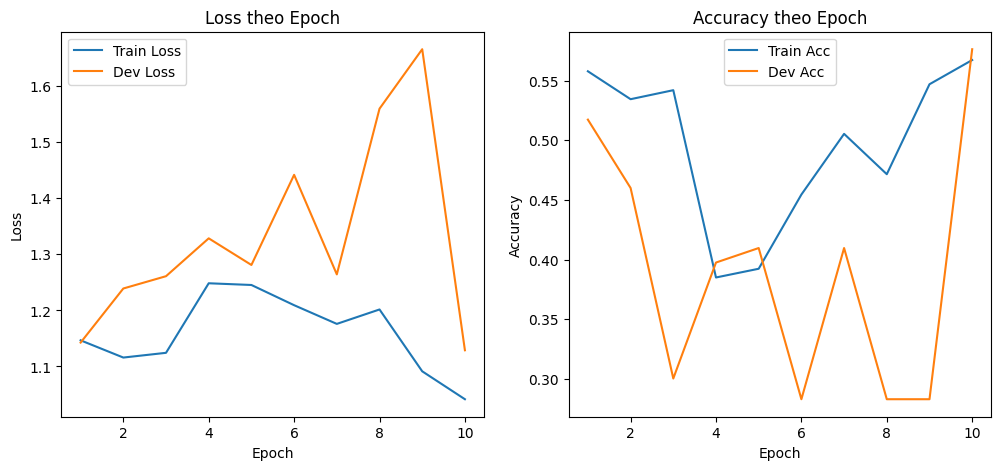

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pad_idx = word2idx['<PAD>']
num_classes = len(domain2idx)

model = DomainClassifier(
    vocab_size=len(word2idx),
    num_classes=num_classes,
    d_model=512, num_heads=8, d_ff=2048,
    num_layers=3, max_len=100, dropout=0.1,
    padding_idx=pad_idx
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses, train_accs, dev_losses, dev_accs = train_model(
    model, train_loader, dev_loader, optimizer, criterion, device,
    num_epochs=10, save_path="domain_best.pt"
)

test_loss, test_acc = test_model(model, test_loader, criterion, device, checkpoint_path="domain_best.pt")

plot_history(train_losses, train_accs, dev_losses, dev_accs)

Loss theo Epoch
- Train Loss dao động từ 1.7 xuống khoảng 1.1, cho thấy mô hình đang học dần tốt hơn trên tập huấn luyện.
- Dev Loss cũng giảm nhưng có xu hướng dao động nhẹ, phản ánh độ ổn định chưa cao trên tập kiểm tra.

Accuracy theo Epoch
- Train Accuracy tăng từ khoảng 0.30 lên gần 0.57, cho thấy mô hình cải thiện khả năng phân loại trên dữ liệu huấn luyện.
- Dev Accuracy cũng tăng nhưng chậm hơn và dao động nhẹ, phản ánh khả năng tổng quát hóa còn hạn chế.

Nhận xét
- Mô hình có tiến triển rõ rệt trong huấn luyện, nhưng hiệu suất trên tập dev chưa ổn định.

Kết quả trên tập Test
- Loss: 1.1073  
- Accuracy: 0.5639  

Nhận xét
- Mức loss cao hơn so với các tập trước, cho thấy mô hình vẫn gặp khó khăn trong việc dự đoán chính xác trên dữ liệu chưa từng thấy.
- Accuracy đạt 56.39%, phản ánh hiệu suất phân loại còn hạn chế, đặc biệt khi so sánh với kết quả huấn luyện.
- Kết quả này phù hợp với xu hướng dao động của Dev Loss và Dev Accuracy, cho thấy khả năng tổng quát hóa của mô hình chưa ổn định.

In [24]:
def plot_confusion_matrix(model, dataloader, device, domain2idx):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)              
            preds = logits.argmax(dim=-1)  

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds, labels=list(domain2idx.values()))

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=list(domain2idx.keys()),
                yticklabels=list(domain2idx.keys()))
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Domain Classification")
    plt.show()


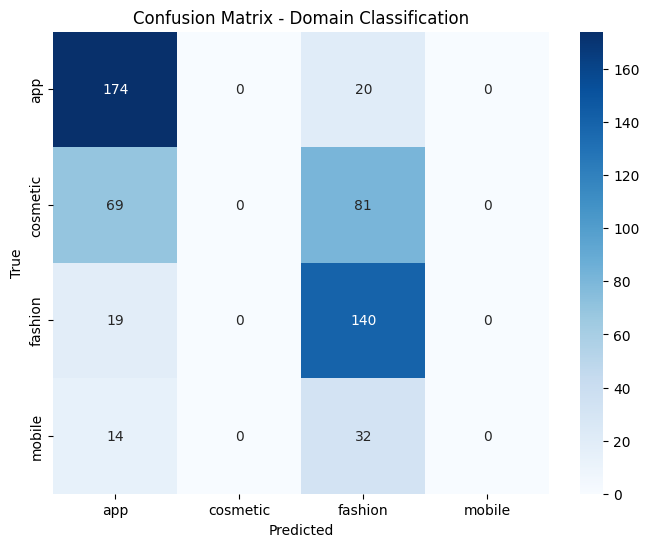

In [25]:
checkpoint = torch.load("domain_best.pt", map_location=device)
model.load_state_dict(checkpoint["model_state"])

plot_confusion_matrix(model, test_loader, device, domain2idx)

Nhận xét
- Mô hình phân loại tốt nhãn app và fashion, với số lượng dự đoán đúng lần lượt là 174 và 140.
- Nhãn cosmetic và mobile không được dự đoán đúng mẫu nào, toàn bộ bị nhầm sang app hoặc fashion.
- Không có dự đoán nào rơi vào nhãn cosmetic hoặc mobile, cho thấy mô hình không học được đặc trưng của hai nhãn này.
- Cần xem xét lại phân phối dữ liệu huấn luyện và khả năng phân biệt đặc trưng giữa các nhãn, đặc biệt là cosmetic và mobile.